<a href="https://colab.research.google.com/github/Kaidense2026/Pop_culture-/blob/main/Pop_Culture_research_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets, model_selection, metrics

In [63]:
import pandas as pd



url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/main/Box%20Office%20Movies%20Data/movies_box_office.csv"



movies = pd.read_csv(url)



movies.head()






,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,8.4,927000.0,Stanley Kubrick,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,5.8,65000.0,Randal Kleiser,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,8.7,1200000.0,Irvin Kershner,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,7.7,221000.0,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,7.3,108000.0,Harold Ramis,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [64]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   score     7665 non-null   float64
 5   votes     7665 non-null   float64
 6   director  7668 non-null   object 
 7   star      7667 non-null   object 
 8   country   7665 non-null   object 
 9   budget    5497 non-null   float64
 10  gross     7479 non-null   float64
 11  company   7651 non-null   object 
 12  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 778.9+ KB


In [65]:
print(movies.shape)

(7668, 13)


In [66]:
movies.describe()

,year,score,votes,budget,gross,runtime
count,7668.000000,7665.000000,7.665000e+03,5.497000e+03,7.479000e+03,7664.000000
mean,2000.405451,6.390411,8.810850e+04,3.558988e+07,7.850054e+07,107.261613
std,11.153508,0.968842,1.633238e+05,4.145730e+07,1.657251e+08,18.581247
min,1980.000000,1.900000,7.000000e+00,3.000000e+03,3.090000e+02,55.000000
25%,1991.000000,5.800000,9.100000e+03,1.000000e+07,4.532056e+06,95.000000
50%,2000.000000,6.500000,3.300000e+04,2.050000e+07,2.020576e+07,104.000000
75%,2010.000000,7.100000,9.300000e+04,4.500000e+07,7.601669e+07,116.000000
max,2020.000000,9.300000,2.400000e+06,3.560000e+08,2.847246e+09,366.000000


Checking for duplicates and nulls:

In [67]:
movies.duplicated().sum()


np.int64(0)

In [68]:
movies[movies.duplicated()]

,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime


In [69]:
movies.isna()

,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,False,True,False,False,False,False,False,False,False,False,True,True,False
7664,False,True,False,False,False,False,False,False,False,True,True,False,False
7665,False,True,False,False,False,False,False,False,False,False,True,False,True
7666,False,True,False,False,True,True,False,False,False,False,True,True,False


In [70]:
movies.isna().sum()

,0
name,0
rating,77
genre,0
year,0
score,3
votes,3
director,0
star,1
country,3
budget,2171


In [71]:
movies[movies['budget'].isnull()]

,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime
16,Fame,R,Drama,1980,6.6,21000.0,Alan Parker,Eddie Barth,United States,NaN,21202829.0,Metro-Goldwyn-Mayer (MGM),134.0
19,Stir Crazy,R,Comedy,1980,6.8,26000.0,Sidney Poitier,Gene Wilder,United States,NaN,101300000.0,Columbia Pictures,111.0
24,Urban Cowboy,PG,Drama,1980,6.4,14000.0,James Bridges,John Travolta,United States,NaN,46918287.0,Paramount Pictures,132.0
25,Altered States,R,Horror,1980,6.9,33000.0,Ken Russell,William Hurt,United States,NaN,19853892.0,Warner Bros.,102.0
26,Little Darlings,R,Comedy,1980,6.5,5100.0,Ron Maxwell,Tatum O'Neal,United States,NaN,34326249.0,Stephen Friedman/Kings Road Productions,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7657,Leap,NaN,Drama,2020,6.7,903.0,Peter Ho-Sun Chan,Gong Li,China,NaN,25818882.0,NaN,135.0
7659,I Am Fear,Not Rated,Horror,2020,3.4,447.0,Kevin Shulman,Kristina Klebe,United States,NaN,13266.0,Roxwell Films,87.0
7660,Aloha Surf Hotel,NaN,Comedy,2020,7.1,14.0,Stefan C. Schaefer,Augie Tulba,United States,NaN,NaN,Abominable Pictures,90.0
7664,Dream Round,NaN,Comedy,2020,4.7,36.0,Dusty Dukatz,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0


In [72]:
movies[movies['gross'].isnull()]

,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime
27,Raise the Titanic,PG,Action,1980,5.0,4100.0,Jerry Jameson,Jason Robards,United Kingdom,36000000.0,NaN,ITC Films,115.0
41,Breaker Morant,PG,Drama,1980,7.9,13000.0,Bruce Beresford,Edward Woodward,Australia,NaN,NaN,The South Australian Film Corporation,107.0
47,The Boogey Man,R,Horror,1980,4.6,3900.0,Ulli Lommel,Suzanna Love,United States,300000.0,NaN,The Jerry Gross Organization,82.0
49,Lion of the Desert,PG,Biography,1980,8.3,15000.0,Moustapha Akkad,Anthony Quinn,Libya,35000000.0,NaN,Falcon International Productions,173.0
52,Can't Stop the Music,PG,Biography,1980,4.2,3700.0,Nancy Walker,Ray Simpson,United States,20000000.0,NaN,EMI Films,124.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,3.1,18.0,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0
7664,Dream Round,NaN,Comedy,2020,4.7,36.0,Dusty Dukatz,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0
7665,Saving Mbango,NaN,Drama,2020,5.7,29.0,Nkanya Nkwai,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN
7666,It's Just Us,NaN,Drama,2020,NaN,NaN,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0


In [73]:
movies[movies['country'].isnull()]

,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime
5728,Saw: The Final Chapter,R,Crime,2010,5.6,93000.0,Kevin Greutert,Tobin Bell,NaN,NaN,NaN,NaN,NaN
5730,The Wolfman,R,Drama,2010,5.8,104000.0,Joe Johnston,Benicio Del Toro,NaN,NaN,NaN,NaN,NaN
7615,Clinton Road,NaN,Horror,2019,5.9,1900.0,Richard Grieco,Ace Young,NaN,2500000.0,50400.0,Growing Tree Productions,77.0


In [74]:
movies['gross'].sum()

np.float64(587105546272.0)

In [75]:
movies['budget'].sum()

np.float64(195637549431.0)

my 3 questions I want to explore for my research project:
What genre is more popular in 1980 and 2020, Horror, Action,Comedy
What genres are more popular in different countries
Are there more Action or Comedy films in 1986 and 2020

My main question:
What genre has more profit in 1980 and 2020, Horror, Action,Comedy

visuals

data cleaning techniques I used:

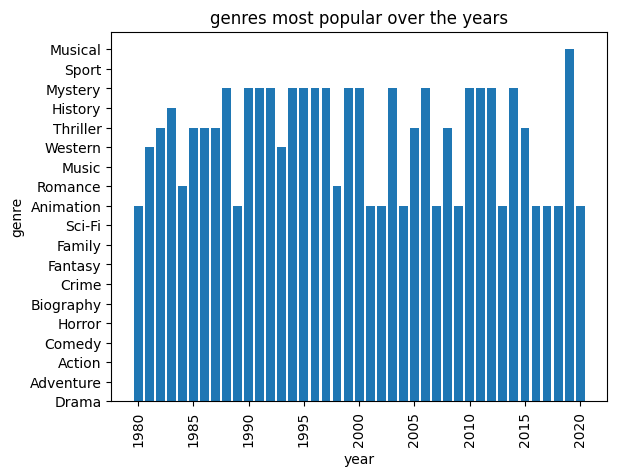

In [79]:
x = movies['year']
y = movies['genre']
plt.bar(x, y)
plt.title('genres most popular over the years')
plt.xlabel('year')
plt.ylabel('genre')
plt.xticks(rotation = 90)
plt.show()

start cleanup

In [77]:
movies.iloc[1981:2020]

,name,rating,genre,year,score,votes,director,star,country,budget,gross,company,runtime
1981,K2,R,Adventure,1991,6.2,6500.0,Franc Roddam,Michael Biehn,United Kingdom,NaN,3106559.0,Paramount Pictures,104.0
1982,Prospero's Books,R,Drama,1991,6.9,6100.0,Peter Greenaway,John Gielgud,United Kingdom,NaN,1750301.0,Allarts,124.0
1983,Pure Luck,PG,Comedy,1991,5.8,6700.0,Nadia Tass,Martin Short,United States,17010000.0,24941969.0,Hivemind,96.0
1984,F/X2,PG-13,Action,1991,5.9,9000.0,Richard Franklin,Bryan Brown,United States,16400000.0,21082165.0,Orion Pictures,108.0
1985,The Adjuster,R,Comedy,1991,6.7,3300.0,Atom Egoyan,Elias Koteas,Canada,NaN,396573.0,Alliance Entertainment,102.0
1986,Mortal Thoughts,R,Mystery,1991,5.7,8400.0,Alan Rudolph,Demi Moore,United States,8000000.0,18784957.0,Columbia Pictures,103.0
1987,Another You,R,Comedy,1991,5.4,3700.0,Maurice Phillips,Richard Pryor,United States,17000000.0,2865916.0,TriStar Pictures,98.0
1988,For the Boys,R,Comedy,1991,6.4,5300.0,Mark Rydell,Bette Midler,United States,40000000.0,23202444.0,All Girl Productions,138.0
1989,Beastmaster 2: Through the Portal of Time,PG-13,Action,1991,4.1,3000.0,Sylvio Tabet,Marc Singer,United States,6000000.0,869325.0,Les Films 21,107.0
1990,McBain,R,Action,1991,4.8,1700.0,James Glickenhaus,Christopher Walken,United States,NaN,456127.0,Marble Hall,102.0
